In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
r  =  20e-3     # m, radi politja petita
# dades motor MAXON, 20W, A-max 2019
n_max = 6460    # rpm, velocitat màxima 
n_nom = 5060    # rpm, velociat nominal
Pot_nom = 120   # W, potència nominal
V_nom = 24      # V, voltatge nominal
R = 3.99        # Ohms, resitència induït
L = 0.556e-3    # H, impedància induït
mmot = 240e-3   # kg, massa motor
Jmot = 45.3e-3*1e-4 # kgm2, inèrcia rotor 45.3 grcm2
bm = 2.8e-6;    # Ns/m, dissipació motor
# dades del reductor 
i = 168;  
mred = 190e-3   # kg, massa reductor
Jred = 0.7e-3*1e-4*i**2 # kgm2, inèrcia 0.7 grcm2
# dimensions
rR = 50e-3;
rP =  40e-3;
pitch = 125e-3;
# masses i inèrcies
mR = 6.5  # kg, massa 
NR = 11;
NC = 5;
JR = 6.2*(25e-3)**2; 
mC = 0.360 # kg, massa
c  = 0.28e-3 # Ns/m

In [3]:
i_t = i/rR;
omega_nom = n_nom*np.pi/30
vC = rR * omega_nom/i

print('\n' + '-'*60)
print(f"{'Velocitats':>12} | {'Valor':>20}")
print('-'*60)
print(f"{'omega motor':>12} | {omega_nom:20.2f}  rad/s")
print(f"{'velocitat paquet':>12} | {vC:20.2f}  m/s")
print('-'*60 + '\n')


------------------------------------------------------------
  Velocitats |                Valor
------------------------------------------------------------
 omega motor |               529.88  rad/s
velocitat paquet |                 0.16  m/s
------------------------------------------------------------



In [4]:
omega_n=n_nom/30*np.pi
M_nom= Pot_nom/omega_n #%-- Nm
A_nom = (omega_n*M_nom)/V_nom 
K_m = M_nom/A_nom  # %-- Nm / A
K_b = V_nom/omega_n  #%-- V s / rad
P_nom = omega_n*M_nom

print('\n' + '-'*60)
print(f"{'Paràmetres':>20} | {'Valor':>20}")
print('-'*60)
print(f"{'Potència nominal':>20} | {P_nom:20.2f}  W")
print(f"{'Moment nominal':>20} | {M_nom:20.2f}  Nm\n")
print(f"{'K_m':>20} | {K_m:20.2f}  Nm/A")
print(f"{'K_b':>20} | {K_b:20.2f}  V s/rad")
print('-'*60 + '\n')


------------------------------------------------------------
          Paràmetres |                Valor
------------------------------------------------------------
    Potència nominal |               120.00  W
      Moment nominal |                 0.23  Nm

                 K_m |                 0.05  Nm/A
                 K_b |                 0.05  V s/rad
------------------------------------------------------------



In [5]:
J_e = Jmot + Jred/i**2 + JR*NR/i**2 + mC*NC/i_t**2
b_e = bm + c/i**2  *NR

# --- MODEL COMPLET ---
num = [K_m]
den = [J_e*L, J_e*R + b_e*L, b_e*R + K_b*K_m]
tf_omg_m = signal.lti(num, den)

num_u = [n / i_t for n in num]  # / i_t per convertir de velocitat angular del motor a velocitat lineal del paquet
den_u = den + [0]               # afegim un zero a l'origen per convertir de velocitat a posició
tf_u_c = signal.lti(num_u, den_u)

# --- MODEL SIMPLIFICAT (L = 0) ---
numS = [K_m]
denS = [J_e*R, b_e*R + K_b*K_m]
tf_omg_mS = signal.lti(numS, denS)

numS_u = [n / i_t for n in numS]  # / i_t per convertir de velocitat angular del motor a velocitat lineal del paquet    
denS_u = denS + [0]               # afegim un zero a l'origen per convertir de velocitat a posició
tf_u_cS = signal.lti(numS_u, denS_u)

tau_e = L/R
tau_m = J_e / (b_e + (K_m*K_b)/R)

print('\n' + '-'*60)
print(f"{'Del paràmetres':>12} | {'Valor':>20}")
print('-'*60)
print(f"{'Tau_e':>12} | {tau_e:20.5f}  s")
print(f"{'Tau_m':>12} | {tau_m:20.5f}  s")
print('-'*60 + '\n')

poles = tf_omg_m.poles
polesS = tf_omg_mS.poles

reals = np.real(poles)
realsS = np.real(polesS)

taus = -1 / reals
tausS = -1 / realsS

print('\n' + '-'*60)
print(f"{'Del pols':>12} | ")
print('-'*60)
print('Pols (complet):', tf_omg_m.poles)
print('Pols (simplificat):', tf_omg_mS.poles)
print('-'*60)
print("Reals (complet):", reals)
print("Reals (simplificat):", realsS)
print('-'*60)
print("Taus (complet):", taus)
print("Taus (simplificat):", tausS)
print('-'*60 + '\n')


------------------------------------------------------------
Del paràmetres |                Valor
------------------------------------------------------------
       Tau_e |              0.00014  s
       Tau_m |              0.01213  s
------------------------------------------------------------


------------------------------------------------------------
    Del pols | 
------------------------------------------------------------
Pols (complet): [-7093.28825223   -83.43473998]
Pols (simplificat): [-82.47008107]
------------------------------------------------------------
Reals (complet): [-7093.28825223   -83.43473998]
Reals (simplificat): [-82.47008107]
------------------------------------------------------------
Taus (complet): [0.00014098 0.01198542]
Taus (simplificat): [0.01212561]
------------------------------------------------------------



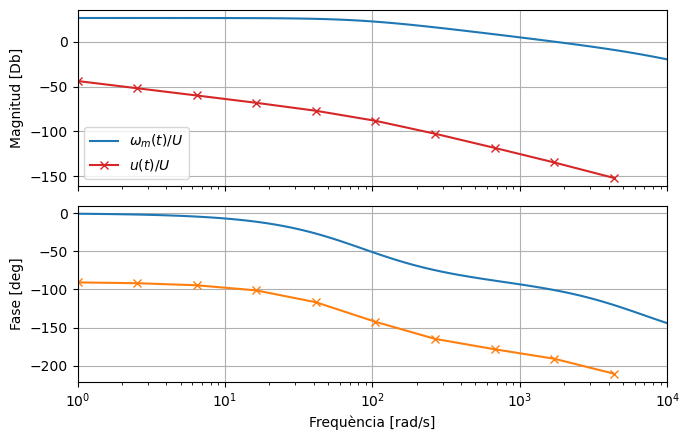

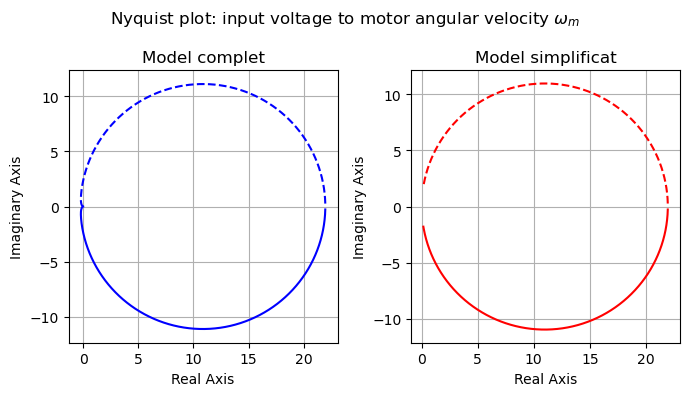

In [6]:
wRange = np.logspace(np.log10(1), np.log10(1e4), num=100)

w, mag, phase    = tf_omg_m.bode(w=wRange)
w_u, mag_u, phase_u = tf_u_c.bode(w=wRange)

plt.subplots(2, 1, sharex='col', figsize=(7,4.5))
plt.subplot(2, 1, 1)
plt.semilogx(w, mag, label =r'$\omega_m(t)/U$')    # Bode magnitude plot
plt.semilogx(w_u[::10], mag_u[::10], '-x', color='tab:red', label = r'$u(t)/U$')    # Bode magnitude plot
plt.ylabel('Magnitud [Db]')
plt.xlim([wRange[0], wRange[-1]])
#plt.title(r'Diagrama de Bode: input: Volts, output: $\omega_m$')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.semilogx(w, phase, label = 'velocitat motor')  # Bode phase plot
plt.semilogx(w_u[::10], phase_u[::10], '-x', label = 'desplaçament carro')  # Bode phase plot
plt.ylabel('Fase [deg]')
plt.xlabel('Frequència [rad/s]')
plt.xlim([wRange[0], wRange[-1]])
plt.grid()

plt.tight_layout()

w, H = tf_omg_m.freqresp()
wS, HS = tf_omg_mS.freqresp()

H = np.squeeze(H)
HS = np.squeeze(HS)

fig, axs = plt.subplots(1, 2, figsize=(7, 4))

axs[0].plot(H.real, H.imag, "b")
axs[0].plot(H.real, -H.imag, "b--")
axs[0].set_title("Model complet")
axs[0].set_xlabel("Real Axis")
axs[0].set_ylabel("Imaginary Axis")
axs[0].axis('equal')
axs[0].grid(True)

axs[1].plot(HS.real, HS.imag, "r")
axs[1].plot(HS.real, -HS.imag, "r--")
axs[1].set_title("Model simplificat")
axs[1].set_xlabel("Real Axis")
axs[1].set_ylabel("Imaginary Axis")
axs[1].axis('equal')
axs[1].grid(True)

fig.suptitle(r"Nyquist plot: input voltage to motor angular velocity $\omega_m$")

plt.tight_layout()

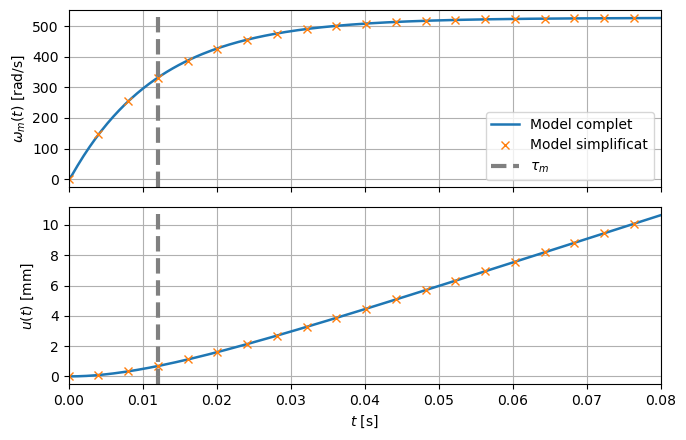

In [7]:

tRange = np.linspace(0, 0.08, num=200)

t, y1 = tf_omg_m.step(T=tRange)
t, y1s = tf_omg_mS.step(T=tRange)
t, y2 = tf_u_c.step(T=tRange)
t, y2s = tf_u_cS.step(T=tRange)

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(7,4.5))

axs[0].plot(t, y1 * V_nom, lw=1.8, label='Model complet')
axs[0].plot(t[::10], y1s[::10] * V_nom, 'x', lw=1.8, label='Model simplificat')
axs[0].axvline(tau_m, color='gray', ls='--', lw=3, label=r'$\tau_m$')
axs[0].set_ylabel(r'$\omega_m(t)$ [rad/s]')
#axs[0].set_title('Resposta a esglaó (' + str(V_nom) + ' V al motor)')
axs[0].grid()
axs[0].set_xlim([0, t[-1]])
axs[0].legend()

axs[1].plot(t, y2 * V_nom * 1e3, lw=1.8, label='Model complet')
axs[1].plot(t[::10], y2s[::10] * V_nom * 1e3, 'x', lw=1.8, label='Model simplificat')
axs[1].axvline(tau_m, color='gray', ls='--', lw=3, label=r'$\tau_m$')
axs[1].set_xlabel(r'$t$ [s]')
axs[1].set_ylabel(r'$u(t)$ [mm]')
axs[1].grid()
axs[1].set_xlim([0, t[-1]])

plt.tight_layout()

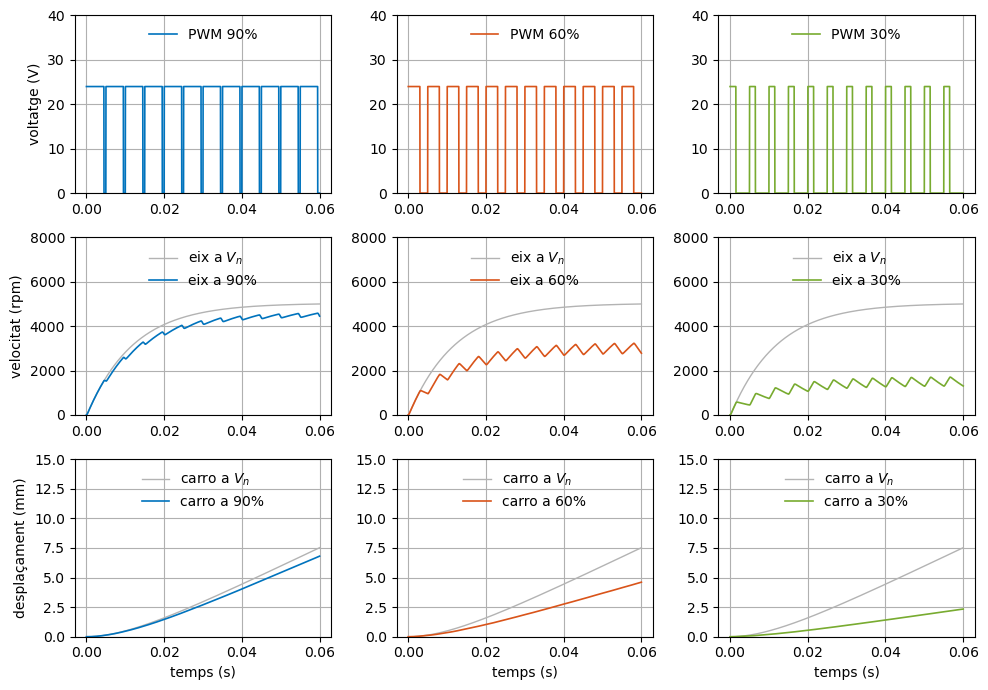

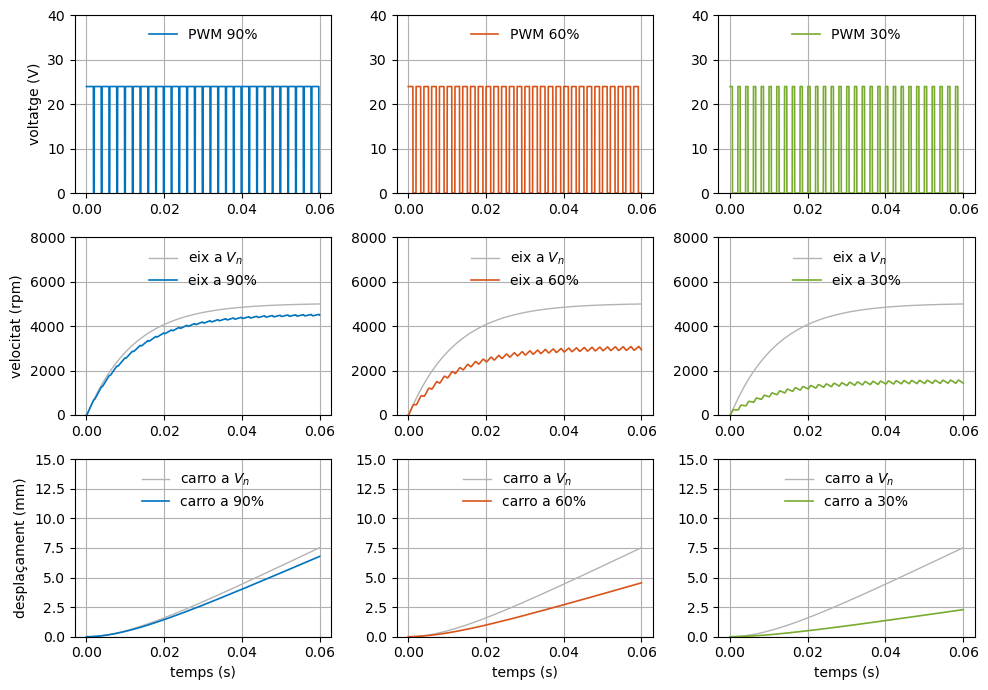

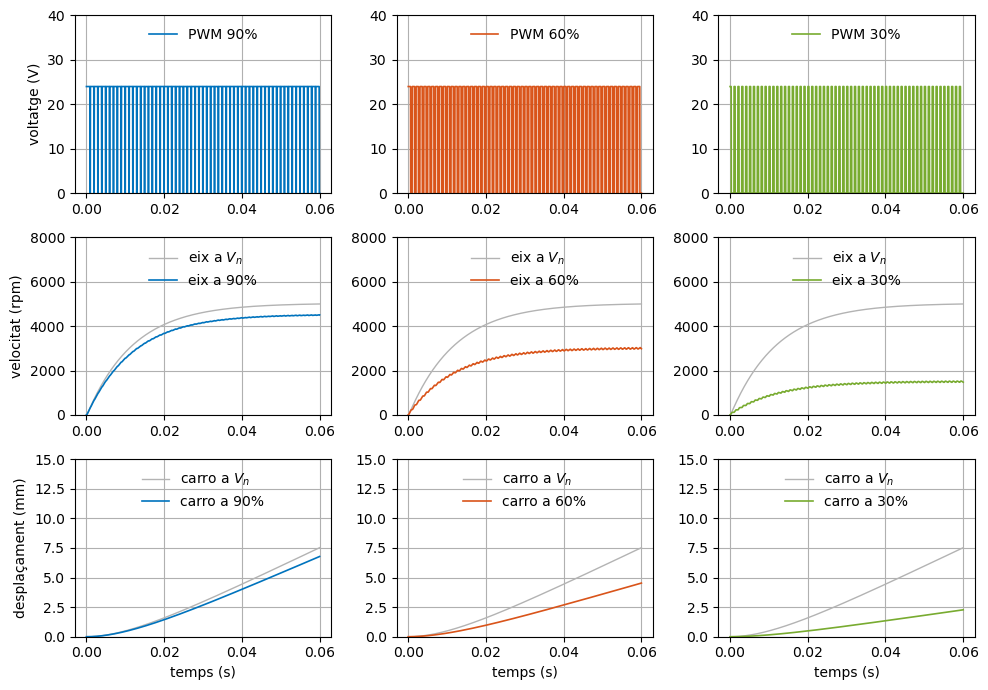

In [8]:

t_f = 0.06
t = np.linspace(0, t_f, 5000)

# =========================
# PWM
# =========================
def pwm_signal(t, duty, Npulses, Vmax):
    T = t[-1]
    y = np.zeros_like(t)
    period = T / Npulses
    on_time = duty/100 * period
    
    for k in range(Npulses):
        t0 = k * period
        t1 = t0 + on_time
        y[(t >= t0) & (t < t1)] = Vmax
        
    return y

# =========================
# SIMULACIÓ PWM
# =========================
def simulate_pwm(t, duty, Npulses, u, sys_omg, sys_u):
    V = pwm_signal(t, duty, Npulses, u)

    _, y_omg, _ = signal.lsim(sys_omg, V, t)
    _, y_u, _   = signal.lsim(sys_u, V, t)

    return V, y_omg, y_u

# =========================
# BASE DC (referència)
# =========================
Vdc = V_nom * np.ones_like(t)

_, y_omg_dc, _ = signal.lsim(tf_omg_m, Vdc, t)
_, y_u_dc, _   = signal.lsim(tf_u_c, Vdc, t)

# =========================
# FIGURA PWM
# =========================
def plot_pwm(Npulses, nompdf='CSM_rodets_din_PWM.pdf'):

    duties = [90, 60, 30]

    colors = [
        (0, 0.45, 0.74),
        (0.85, 0.33, 0.10),
        (0.47, 0.67, 0.19)
    ]

    plt.figure(figsize=(10,7))

    for i, (duty, col) in enumerate(zip(duties, colors)):

        V, y_omg, y_u = simulate_pwm(t, duty, Npulses, V_nom, tf_omg_m, tf_u_c)

        # --- VOLTATGE
        plt.subplot(3,3,i+1)
        plt.plot(t, V, color=col, linewidth=1.2)
        plt.legend([f'PWM {duty}%'], loc='upper center', frameon=False)
        plt.ylim([0,40])
        plt.grid()
        if i == 0:
            plt.ylabel('voltatge (V)')

        # --- VELOCITAT
        plt.subplot(3,3,i+4)
        plt.plot(t, y_omg_dc*30/np.pi, color=(0.7,0.7,0.7), linewidth=1.0)
        plt.plot(t, y_omg*30/np.pi, color=col, linewidth=1.2)
        plt.legend([r'eix a $V_n$', f'eix a {duty}%'], loc='upper center', frameon=False)
        plt.ylim([0,8000])
        plt.grid()
        if i == 0:
            plt.ylabel('velocitat (rpm)')

        # --- DESPLAÇAMENT
        plt.subplot(3,3,i+7)
        plt.plot(t, y_u_dc*1e3, color=(0.7,0.7,0.7), linewidth=1.0)
        plt.plot(t, y_u*1e3, color=col, linewidth=1.2)
        plt.legend([r'carro a $V_n$', f'carro a {duty}%'], loc='upper center', frameon=False)
        plt.ylim([0,15])
        plt.grid()
        plt.xlabel('temps (s)')
        if i == 0:
            plt.ylabel('desplaçament (mm)')

    plt.tight_layout()
    # plt.savefig(nompdf, bbox_inches='tight', transparent=True)


# =========================
# EXECUCIÓ (MATLAB H04 / H05)
# =========================
plot_pwm(12,nompdf='CSM_rodets_din_PWM12.pdf')
plot_pwm(30,nompdf='CSM_rodets_din_PWM30.pdf')
plot_pwm(60,nompdf='CSM_rodets_din_PWM60.pdf')

In [9]:
# % Matrius de massa M_, esmorteïment C_ i rigidesa K_

b_e_ = b_e + (K_m*K_b)/R # esmorteïment equivalent que inclou el terme de retroacció de velocitat del motor (K_b) i la força electromotriu (K_m) que apareix a la dinàmica del motor. Aquest terme és important per a modelar correctament el comportament del sistema, ja que representa la dissipació addicional causada per la interacció entre el motor i la càrrega.
f_v = np.array([[K_m / R]])  # input (1x1)

M_ = np.array([[J_e]])
C_ = np.array([[b_e_]])
K_ = np.array([[0]])

n_gdl = M_.shape[0]

# --- A, B ---
A = np.block([
    [np.zeros((n_gdl, n_gdl)), np.eye(n_gdl)],
    [-np.linalg.inv(M_) @ K_,  -np.linalg.inv(M_) @ C_]
])

B = np.block([
    [np.zeros((n_gdl, 1))],
    [np.linalg.inv(M_) @ f_v]
])

# --- C, D ---
C = np.array([
    [0,     1],
    [1/i_t, 0]
])

D = np.zeros((2, 1))

# --- Sisteme SISO ---
C1 = C[0:1, :]
D1 = D[0:1, :]
model1 = signal.StateSpace(A, B, C1, D1)

C2 = C[1:2, :]
D2 = D[1:2, :]
model2 = signal.StateSpace(A, B, C2, D2)

/Users/mayugo/miniconda3/envs/manim/lib/python3.10/site-packages/scipy/signal/_filter_design.py:1125: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


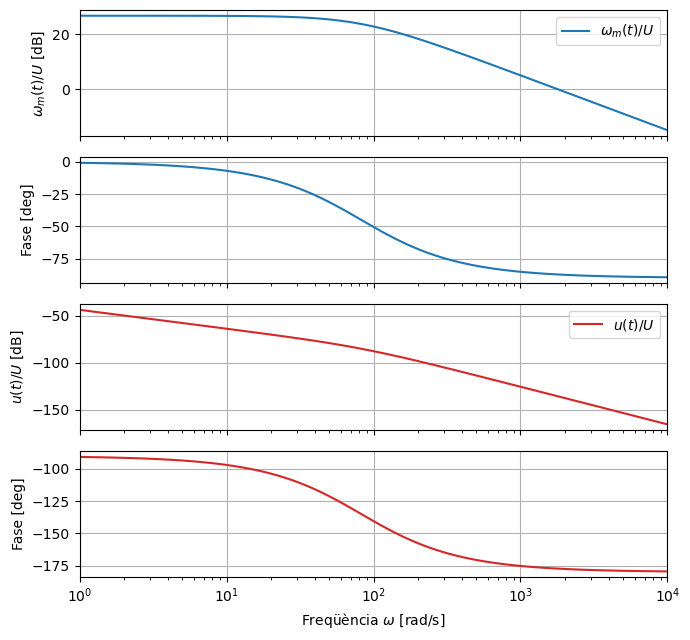

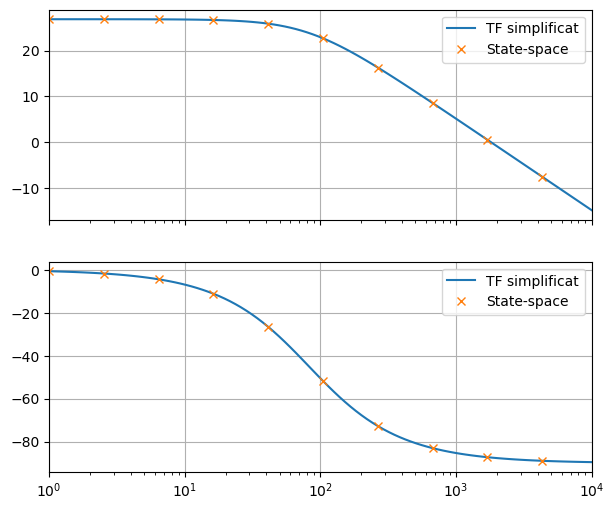

In [10]:

w, mag1, phase1 = signal.bode(model1, w=wRange)
w, mag2, phase2 = signal.bode(model2, w=wRange)

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(7,6.5))

axs[0].semilogx(w, mag1, label=r'$\omega_m(t)/U$')
axs[0].set_ylabel(r'$\omega_m(t)/U$ [dB]')
axs[0].set_xlim([wRange[0], wRange[-1]])
axs[0].grid()
axs[0].legend()

axs[2].semilogx(w, mag2, color='tab:red', label=r'$u(t)/U$')
axs[2].set_ylabel(r'$u(t)/U$ [dB]')
axs[2].set_xlim([wRange[0], wRange[-1]])
axs[2].grid()
axs[2].legend()

axs[1].semilogx(w, phase1)
axs[1].set_ylabel("Fase [deg]")
axs[1].set_xlim([wRange[0], wRange[-1]])
axs[1].grid()

axs[3].semilogx(w, phase2, color='tab:red')
axs[3].set_ylabel("Fase [deg]")
axs[3].set_xlim([wRange[0], wRange[-1]])
axs[3].set_xlabel(r"Freqüència $\omega$ [rad/s]")
axs[3].grid()

plt.tight_layout()

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(7,6))

w, mag_tfS, phase_tfS = tf_omg_mS.bode(w=wRange)
w, mag_ss, phase_ss = signal.bode(model1, w=wRange)

axs[0].semilogx(w, mag_tfS, label="TF simplificat")
axs[0].semilogx(w[::10], mag_ss[::10], 'x', label="State-space")
axs[0].set_xlim([wRange[0], wRange[-1]])
axs[0].legend()
axs[0].grid()

axs[1].semilogx(w, phase_tfS, label="TF simplificat")
axs[1].semilogx(w[::10], phase_ss[::10], 'x', label="State-space")
axs[1].set_xlim([wRange[0], wRange[-1]])
axs[1].legend()
axs[1].grid()

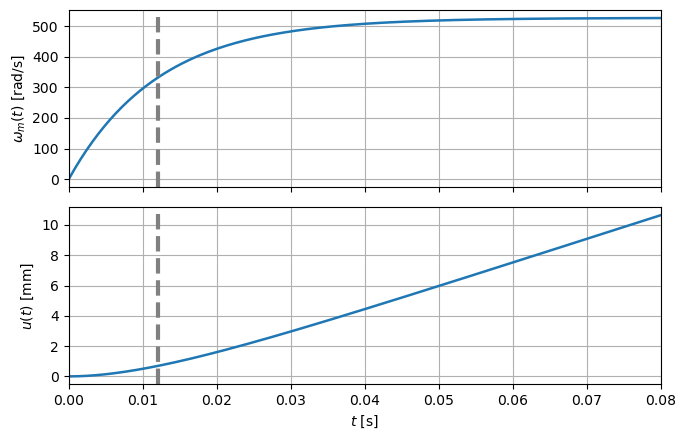

In [11]:

tRange = np.linspace(0, 0.08, num=200)

t, y1 = model1.step(T=tRange)
t, y2 = model2.step(T=tRange)

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(7,4.5))

# --- omega_m ---
axs[0].plot(t, y1 * V_nom, lw=1.8, label=r'$\omega_m(t)/U$')
axs[0].axvline(tau_m, color='gray', ls='--', lw=3, label=r'$\tau_m$')
axs[0].set_ylabel(r'$\omega_m(t)$ [rad/s]')
#axs[0].set_title('Resposta a esglaó (' + str(V_nom) + ' V al motor)')
axs[0].grid()
axs[0].set_xlim([0, t[-1]])

# --- desplaçament ---
axs[1].plot(t, y2 * V_nom * 1e3, lw=1.8, label=r'$u(t)/U$')
axs[1].axvline(tau_m, color='gray', ls='--', lw=3, label=r'$\tau_m$')
axs[1].set_xlabel(r'$t$ [s]')
axs[1].set_ylabel(r'$u(t)$ [mm]')
axs[1].grid()
axs[1].set_xlim([0, t[-1]])

plt.tight_layout()

plt.show()